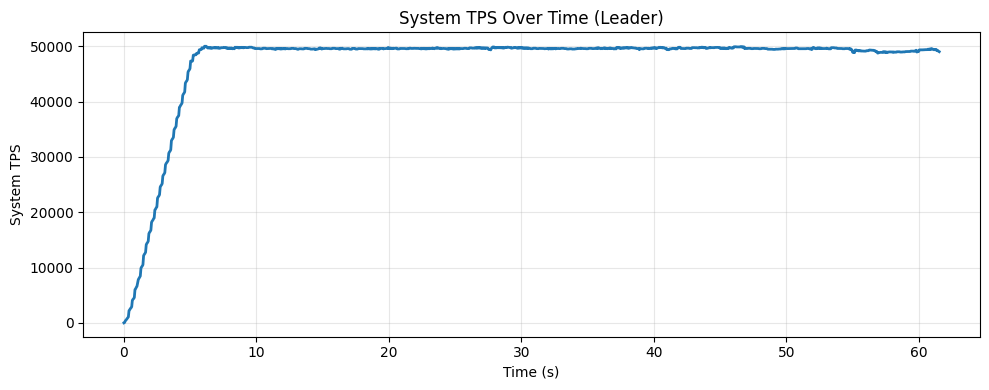

          Timestamp  SystemTPS
1226  1774647023445    49222.0
1227  1774647023477    49288.0
1228  1774647023527    49222.0
1229  1774647023577    49095.0
1230  1774647023627    49027.0


In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "system_tps_global.csv"

if not os.path.exists(csv_path):
    print(f"{csv_path} not found. Run the experiment first.")
else:
    df = pd.read_csv(csv_path)
    if df.empty:
        print(f"{csv_path} is empty.")
    else:
        if "Timestamp" not in df.columns or "SystemTPS" not in df.columns:
            print("Expected columns: Timestamp,SystemTPS")
        else:
            df = df.sort_values("Timestamp").copy()
            df["time_s"] = (df["Timestamp"] - df["Timestamp"].iloc[0]) / 1000.0

            plt.figure(figsize=(10, 4))
            plt.plot(df["time_s"], df["SystemTPS"], linewidth=2, color="#1f77b4")
            plt.title("System TPS Over Time (Leader)")
            plt.xlabel("Time (s)")
            plt.ylabel("System TPS")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

            print(df[["Timestamp", "SystemTPS"]].tail())

Plotting System Metrics

1. Plotting TPS metrics...
File not found: ./tps_3.csv
File not found: ./tps_4.csv
File not found: ./tps_5.csv
File not found: ./tps_6.csv
File not found: ./tps_7.csv
File not found: ./tps_8.csv
File not found: ./tps_9.csv
File not found: ./tps_10.csv
File not found: ./tps_11.csv
File not found: ./tps_12.csv
File not found: ./tps_13.csv
File not found: ./tps_14.csv


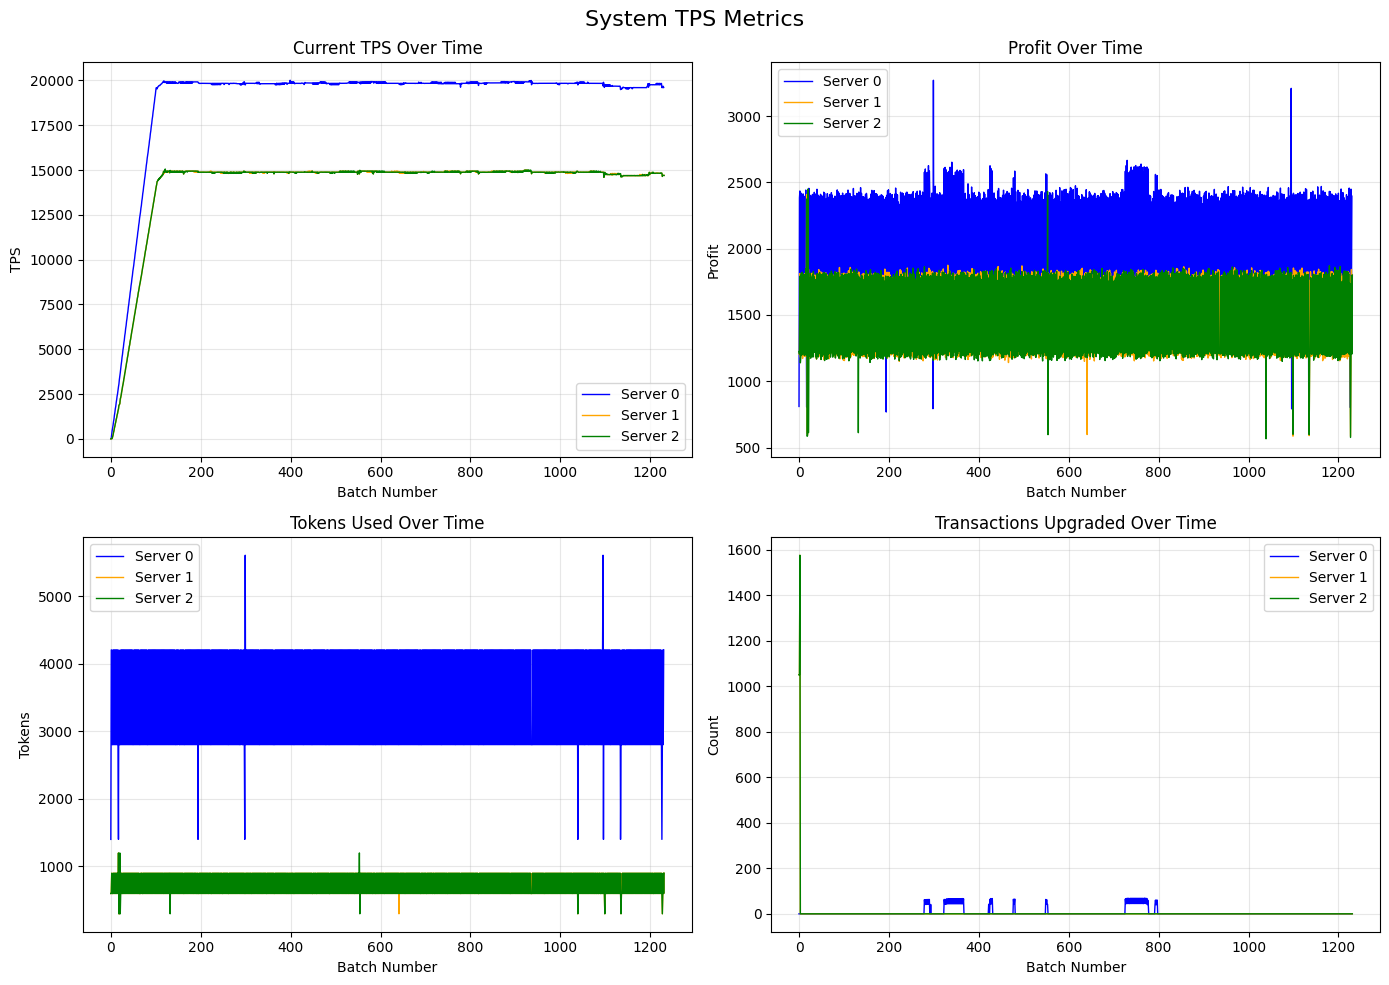


2. Plotting Incoming Transaction Rate...
File not found: ./incoming_transaction_rate_0.csv
File not found: ./incoming_transaction_rate_1.csv
File not found: ./incoming_transaction_rate_2.csv
File not found: ./incoming_transaction_rate_3.csv
File not found: ./incoming_transaction_rate_4.csv
File not found: ./incoming_transaction_rate_5.csv
File not found: ./incoming_transaction_rate_6.csv
File not found: ./incoming_transaction_rate_7.csv
File not found: ./incoming_transaction_rate_8.csv
File not found: ./incoming_transaction_rate_9.csv
File not found: ./incoming_transaction_rate_10.csv
File not found: ./incoming_transaction_rate_11.csv
File not found: ./incoming_transaction_rate_12.csv
File not found: ./incoming_transaction_rate_13.csv
File not found: ./incoming_transaction_rate_14.csv


/tmp/ipykernel_268177/3090985997.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].grid(True, alpha=0.3); axes[0].legend()
/tmp/ipykernel_268177/3090985997.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].grid(True, alpha=0.3); axes[1].legend()


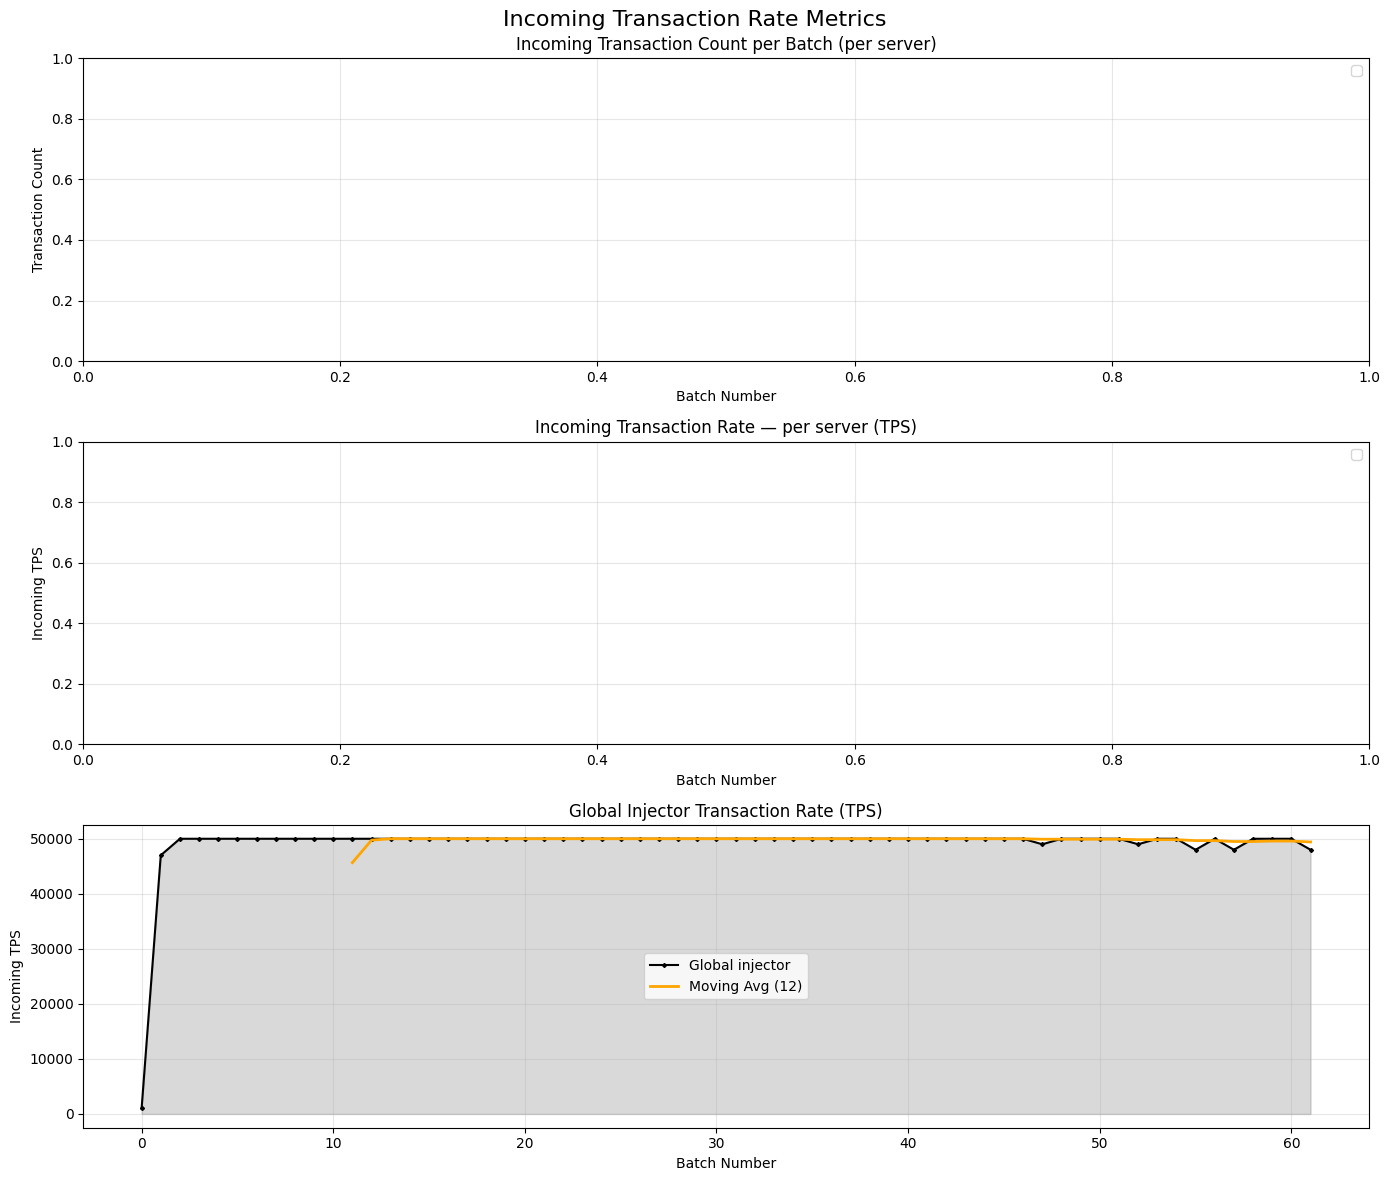


3. Plotting Backlog...
File not found: ./backlog_3.csv
File not found: ./backlog_4.csv
File not found: ./backlog_5.csv
File not found: ./backlog_6.csv
File not found: ./backlog_7.csv
File not found: ./backlog_8.csv
File not found: ./backlog_9.csv
File not found: ./backlog_10.csv
File not found: ./backlog_11.csv
File not found: ./backlog_12.csv
File not found: ./backlog_13.csv
File not found: ./backlog_14.csv


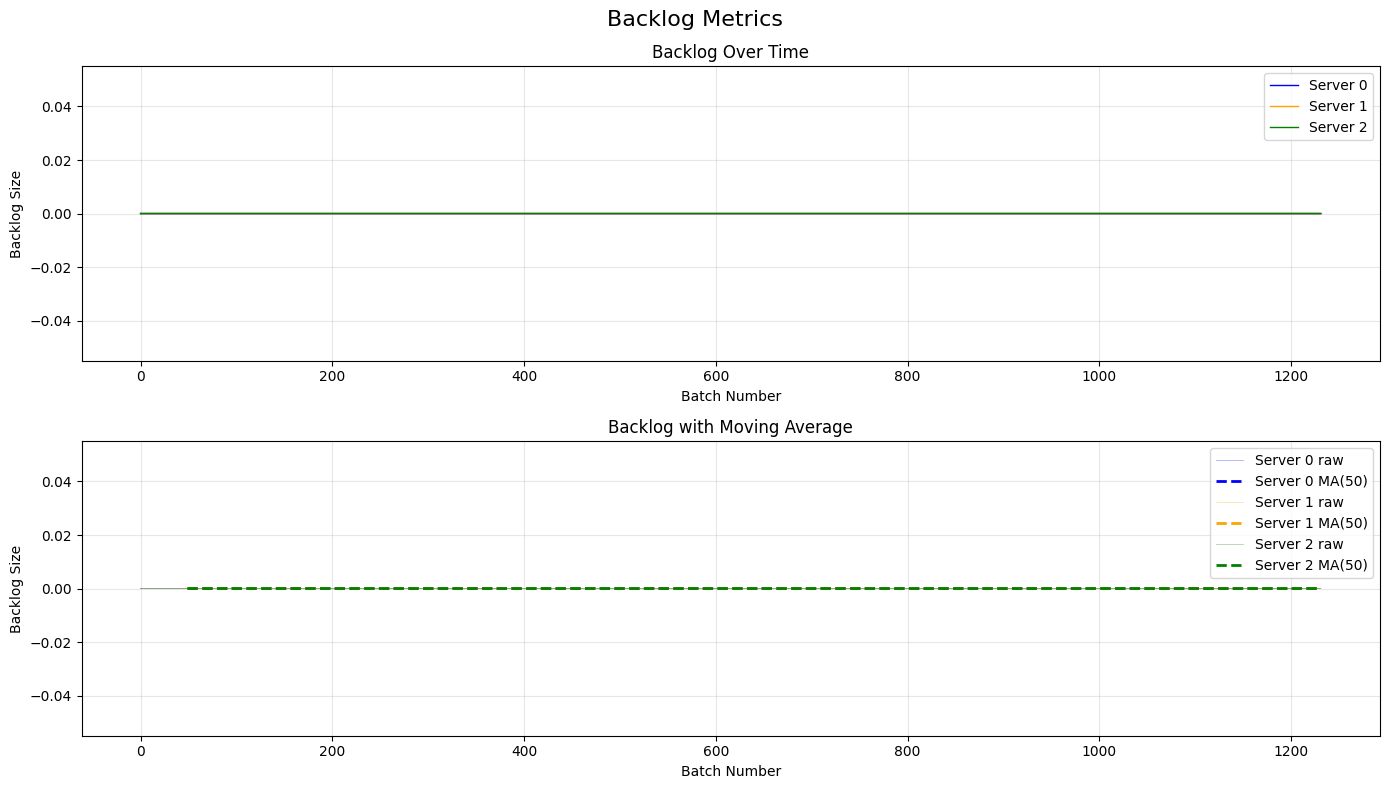


4. Plotting WriteConcern Frequency...


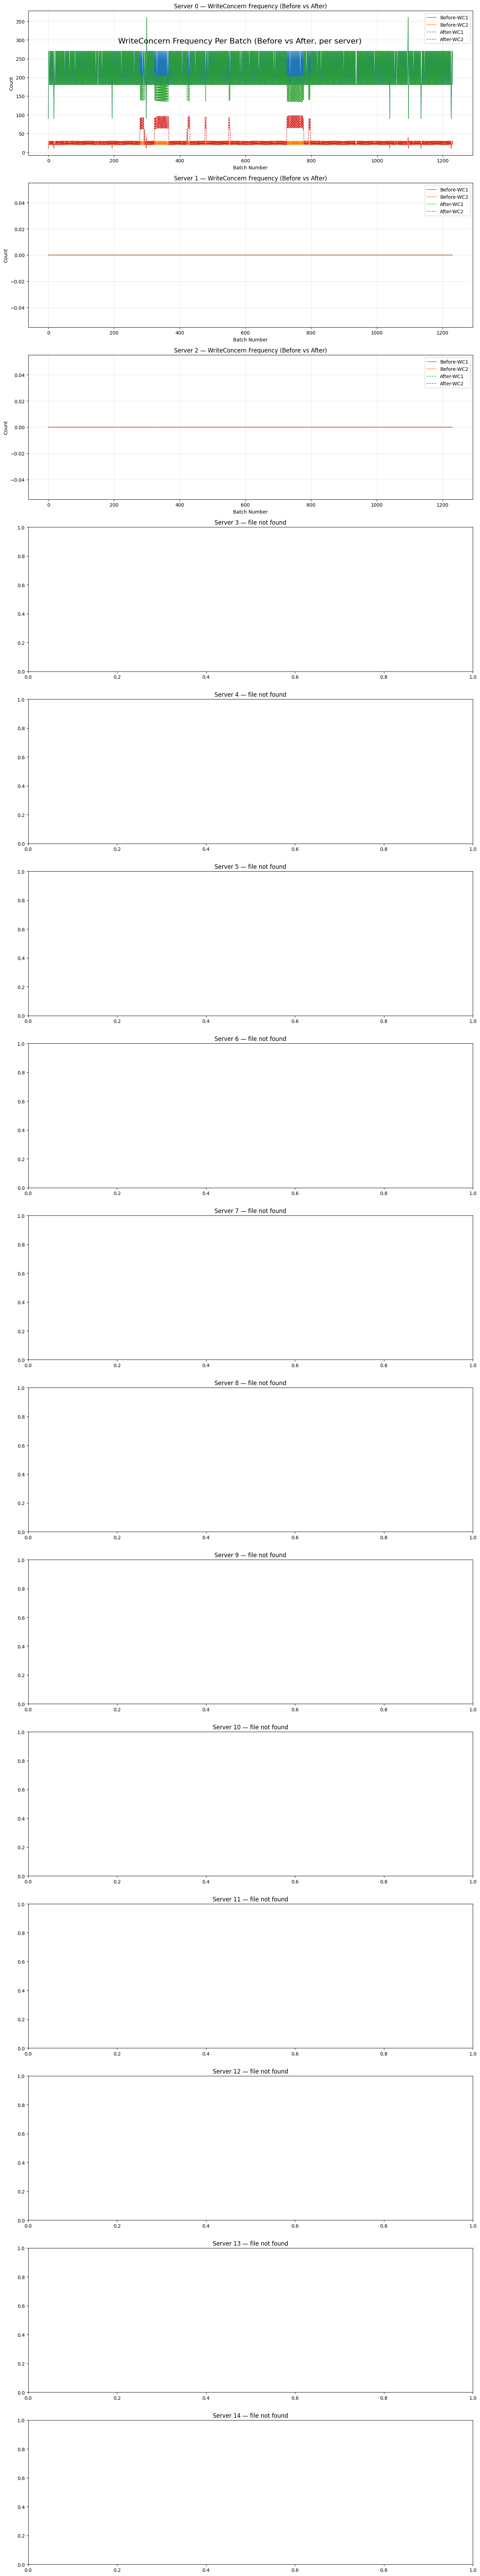


5. Plotting Read Mix (Before vs After)...


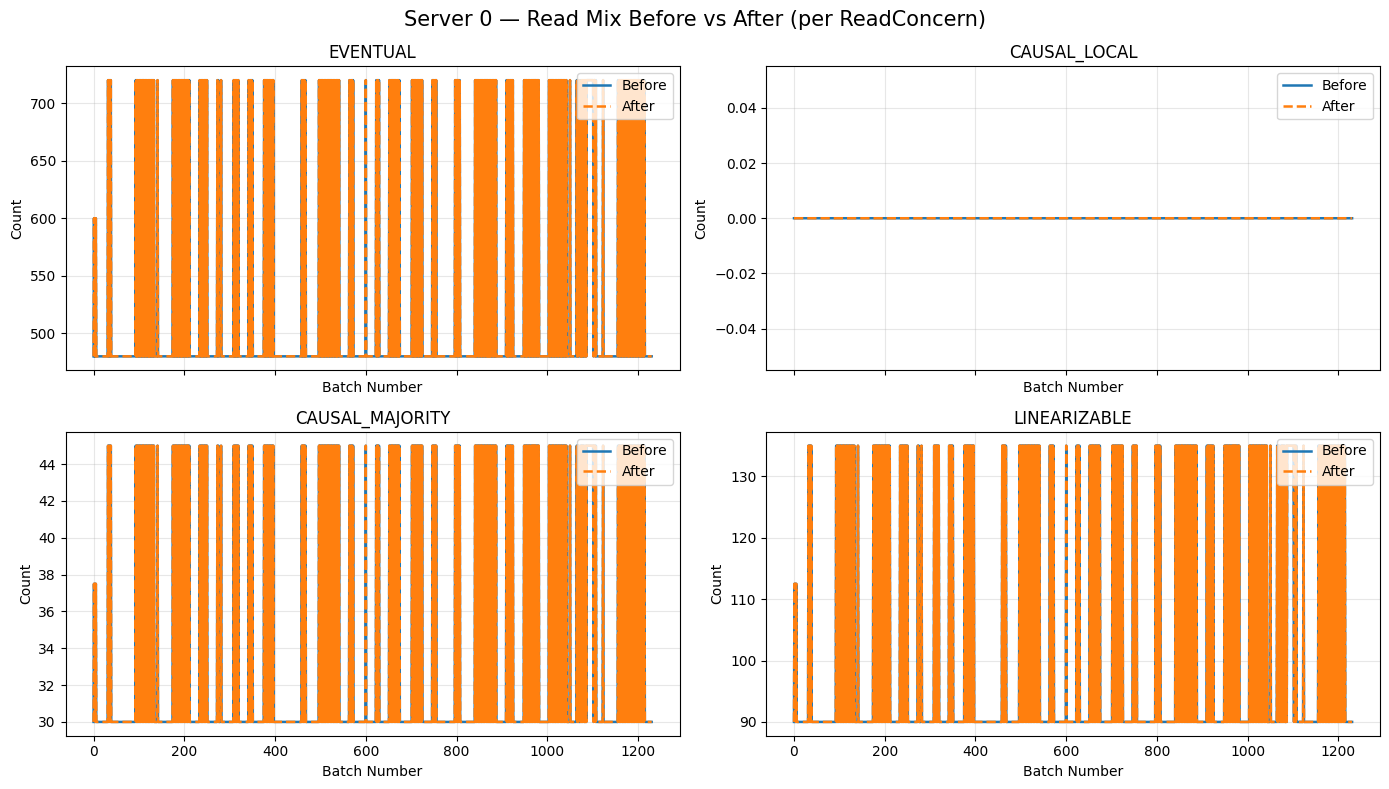

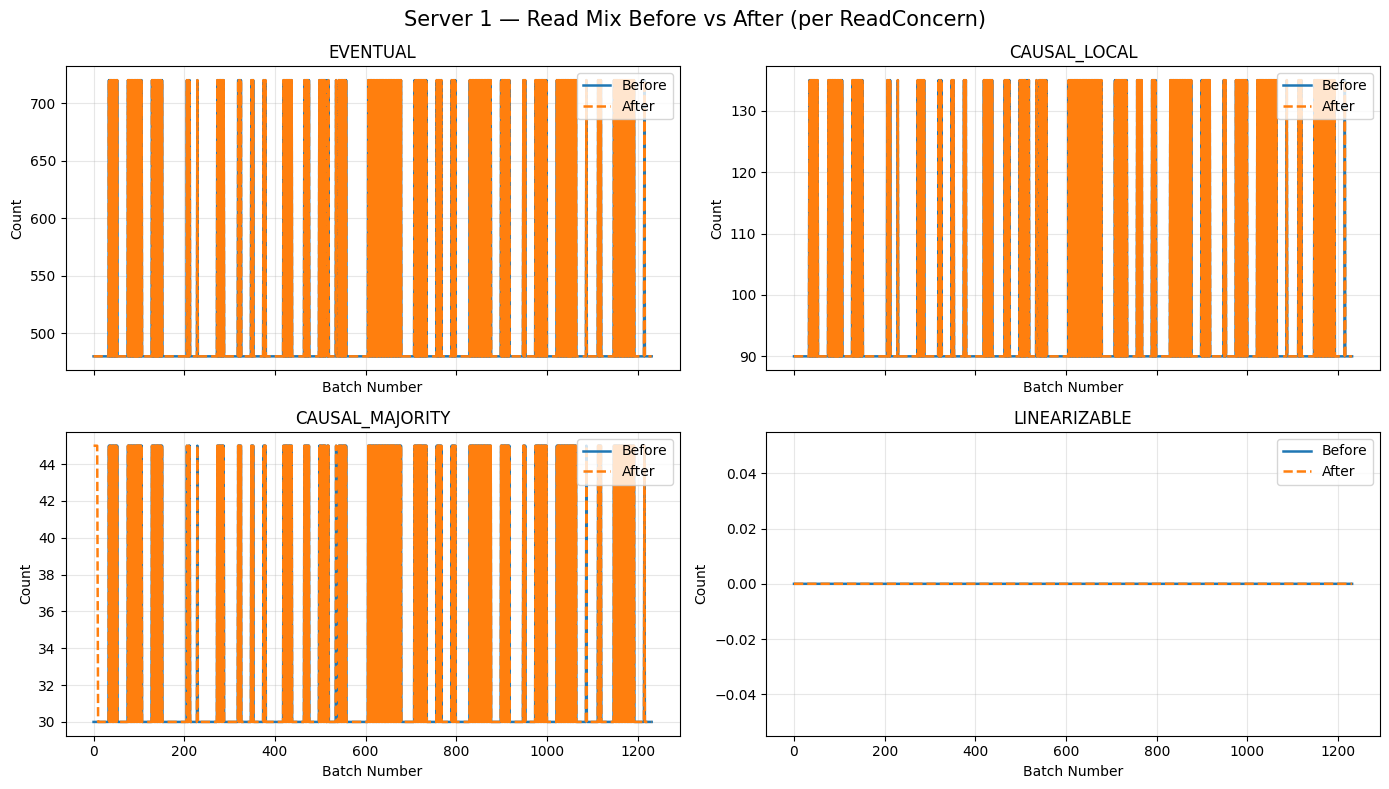

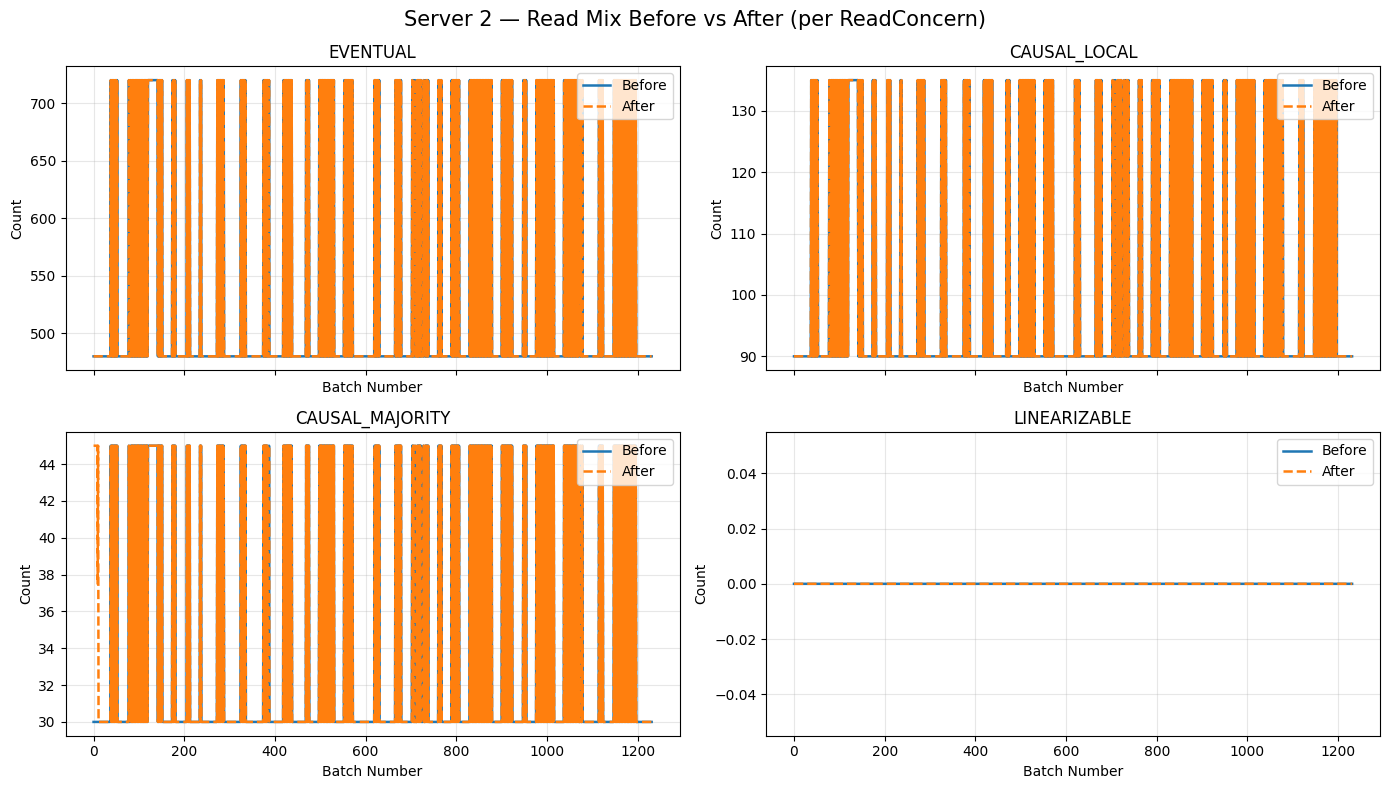

File not found: ./batch_mix_before_after_3.csv
File not found: ./batch_mix_before_after_4.csv
File not found: ./batch_mix_before_after_5.csv
File not found: ./batch_mix_before_after_6.csv
File not found: ./batch_mix_before_after_7.csv
File not found: ./batch_mix_before_after_8.csv
File not found: ./batch_mix_before_after_9.csv
File not found: ./batch_mix_before_after_10.csv
File not found: ./batch_mix_before_after_11.csv
File not found: ./batch_mix_before_after_12.csv
File not found: ./batch_mix_before_after_13.csv
File not found: ./batch_mix_before_after_14.csv

6. Plotting WriteConcern TPS...


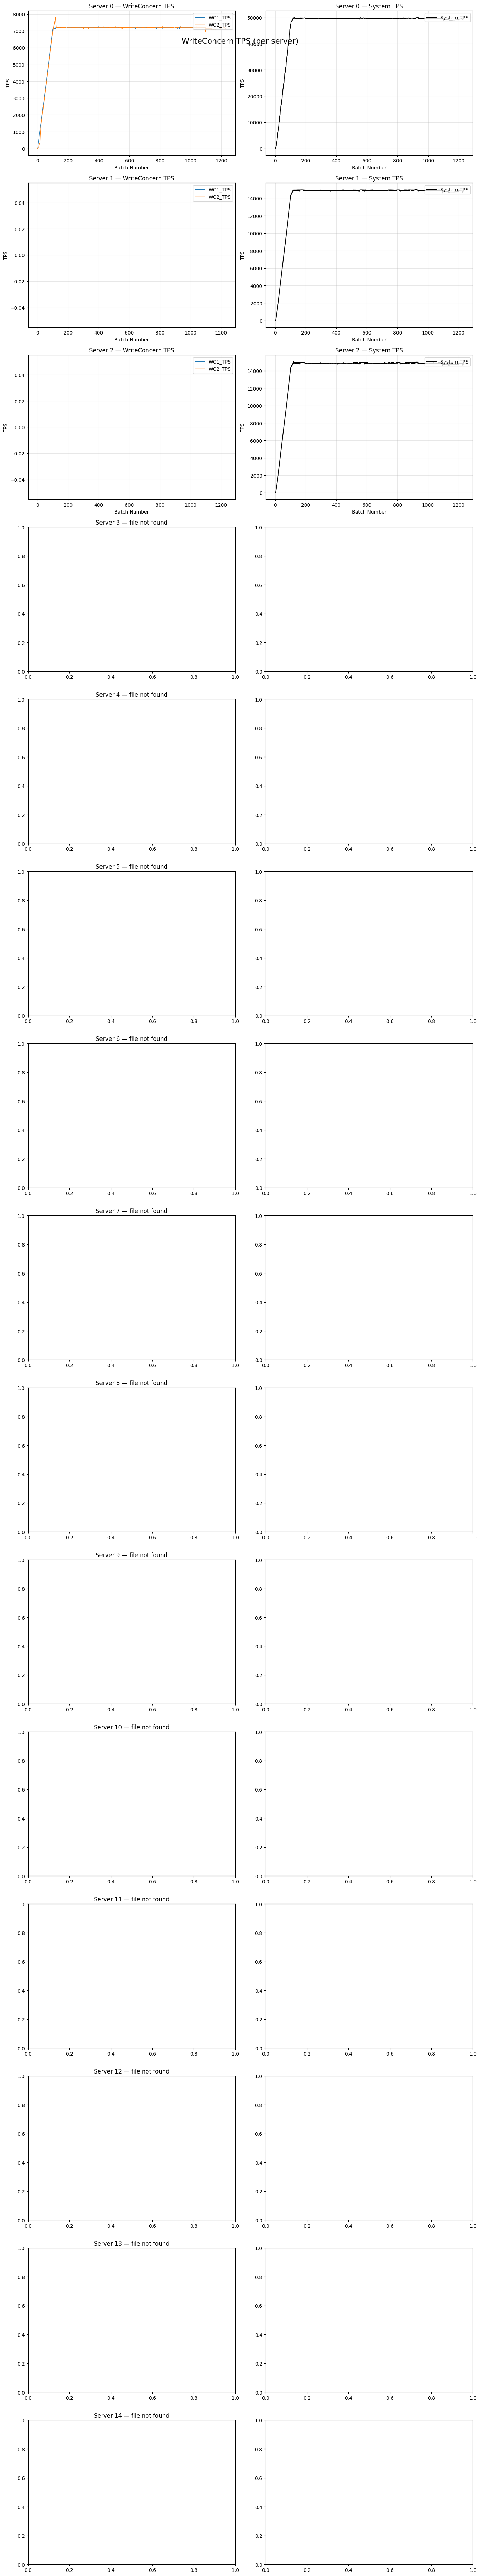


7. Plotting Final Batch Average TPS...
File not found: ./final_batch_avg_tps_log.csv

8. Plotting Combined Dashboard...


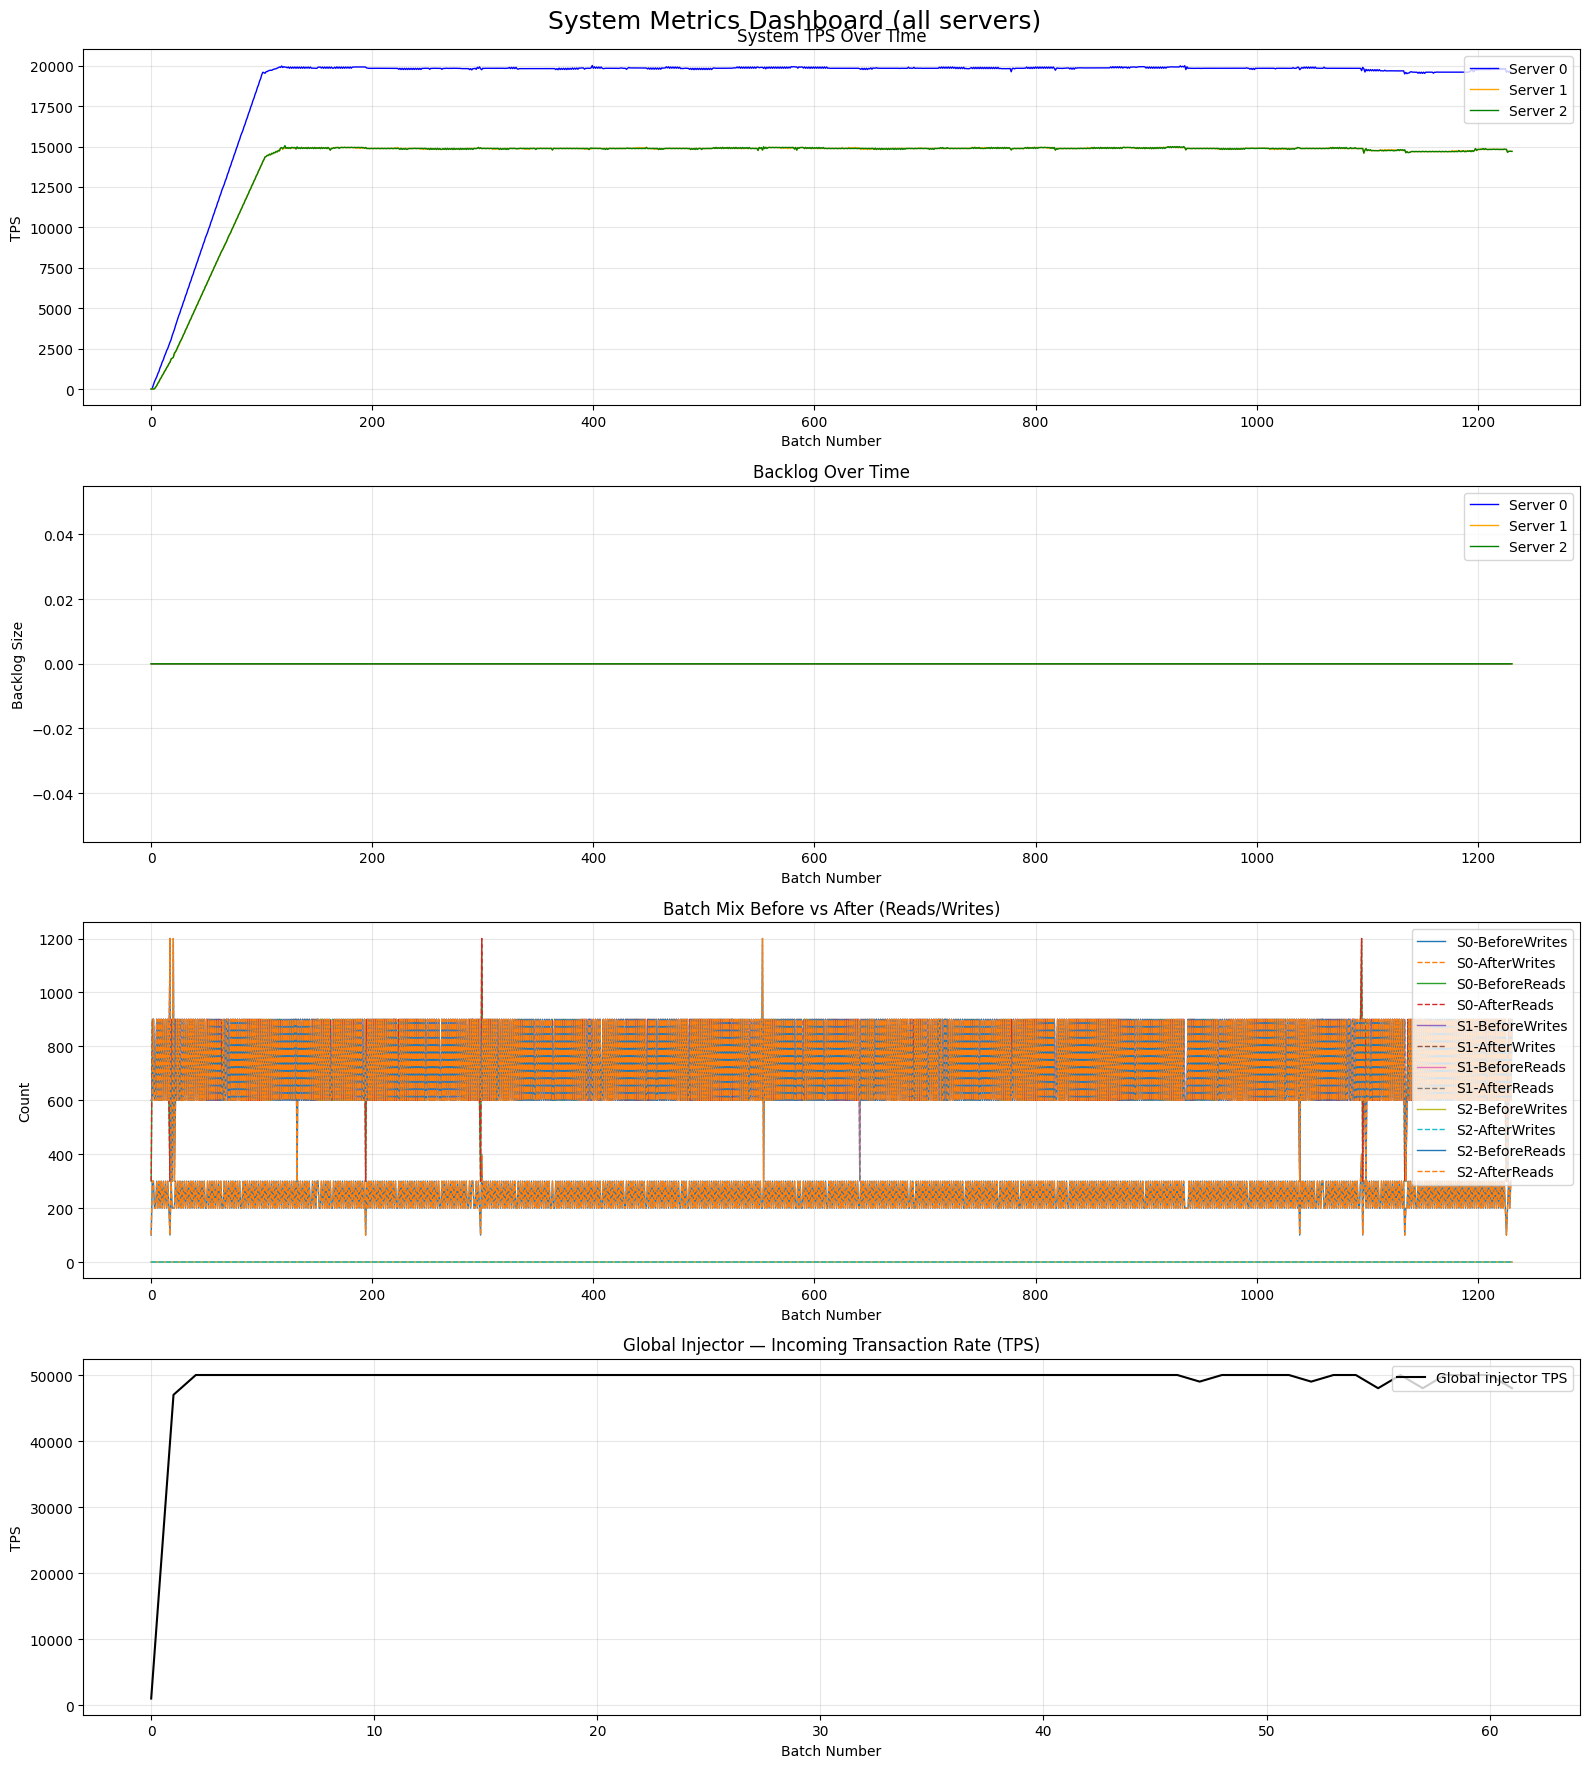


9. Plotting Stacked Area Chart...


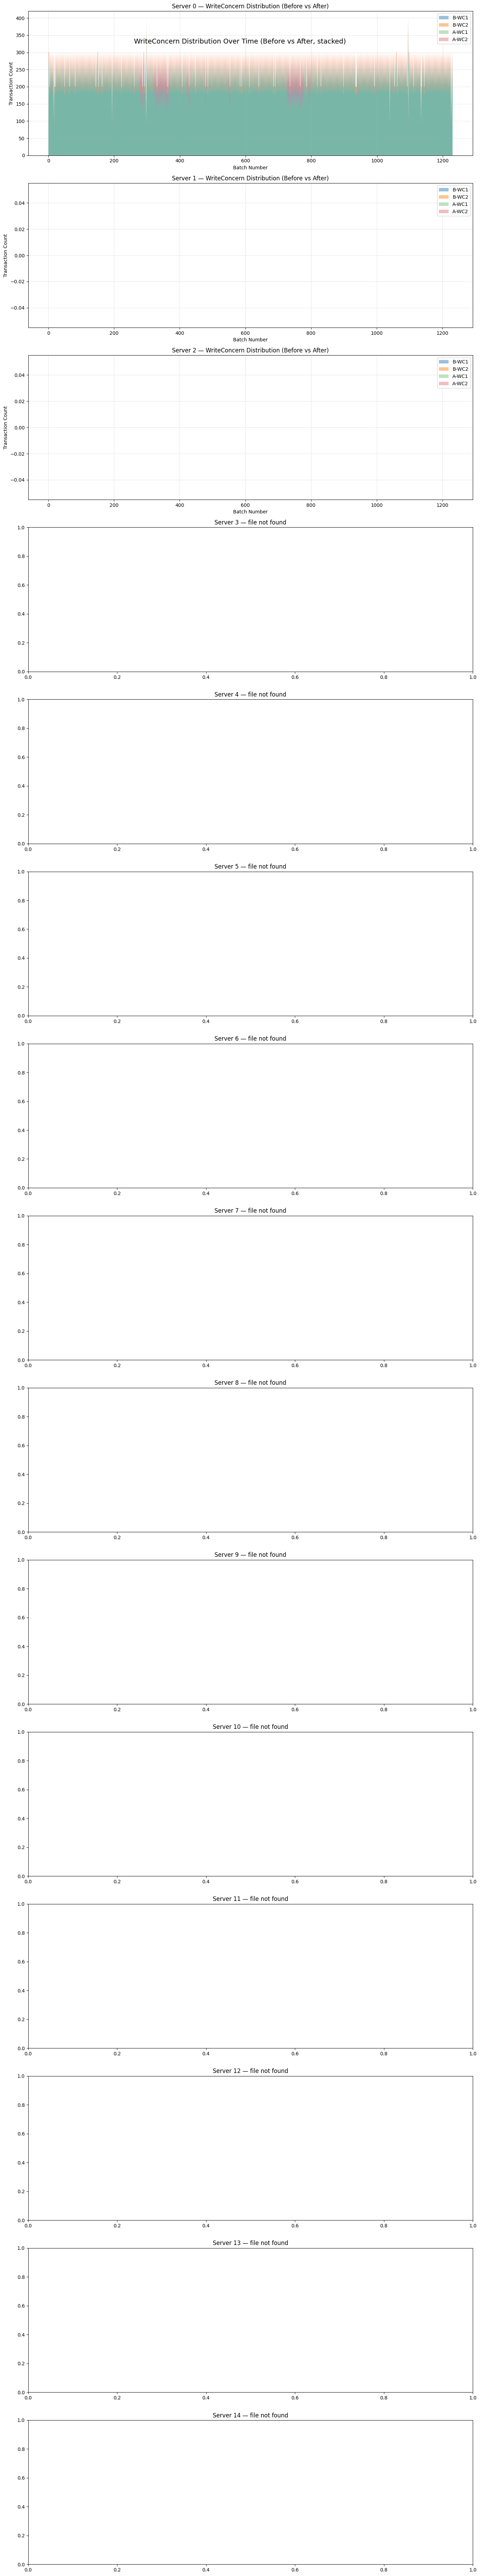


10. Plotting Workload Before Upgrade (Per Server)...


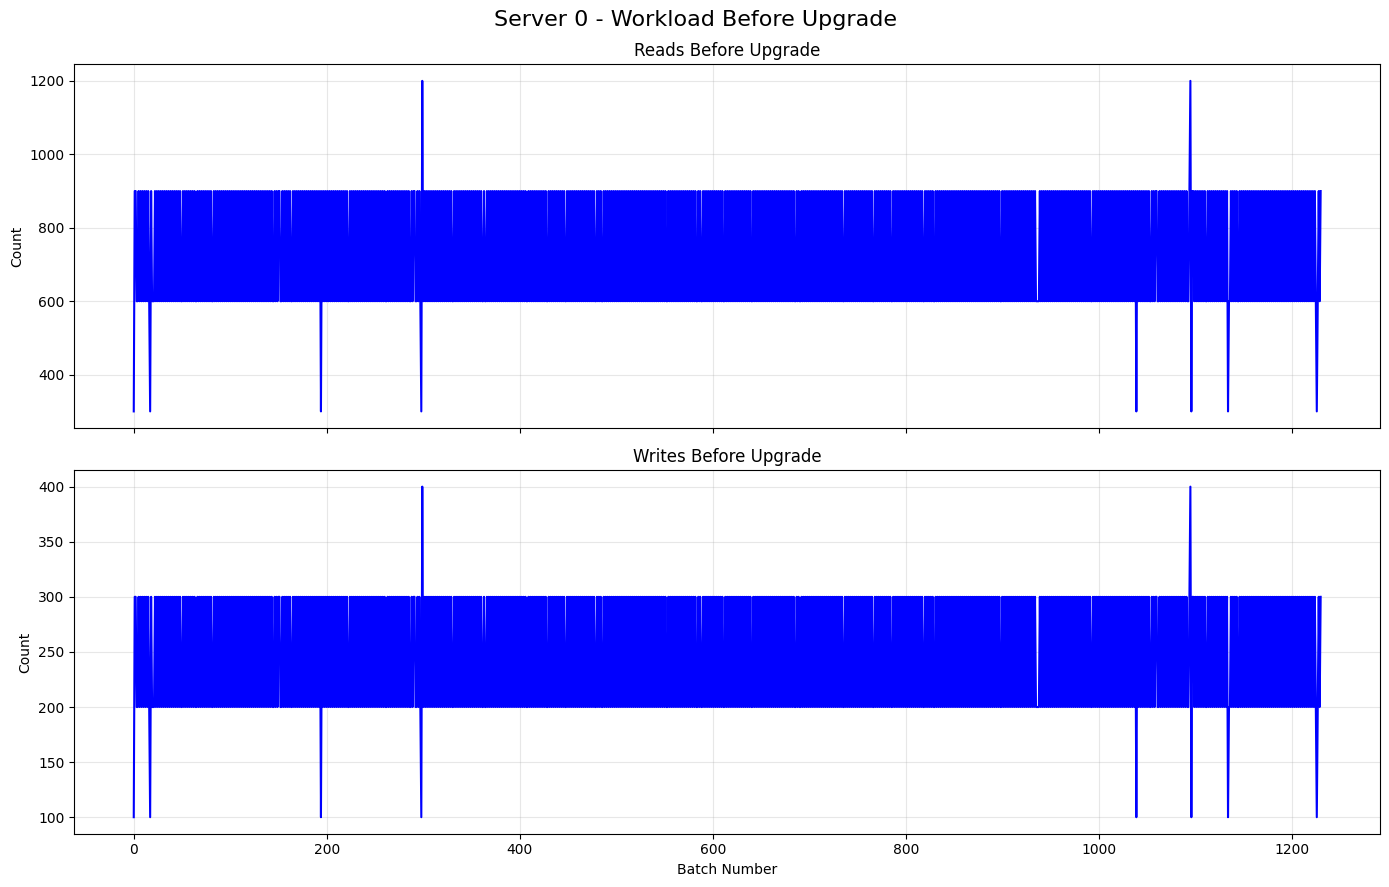

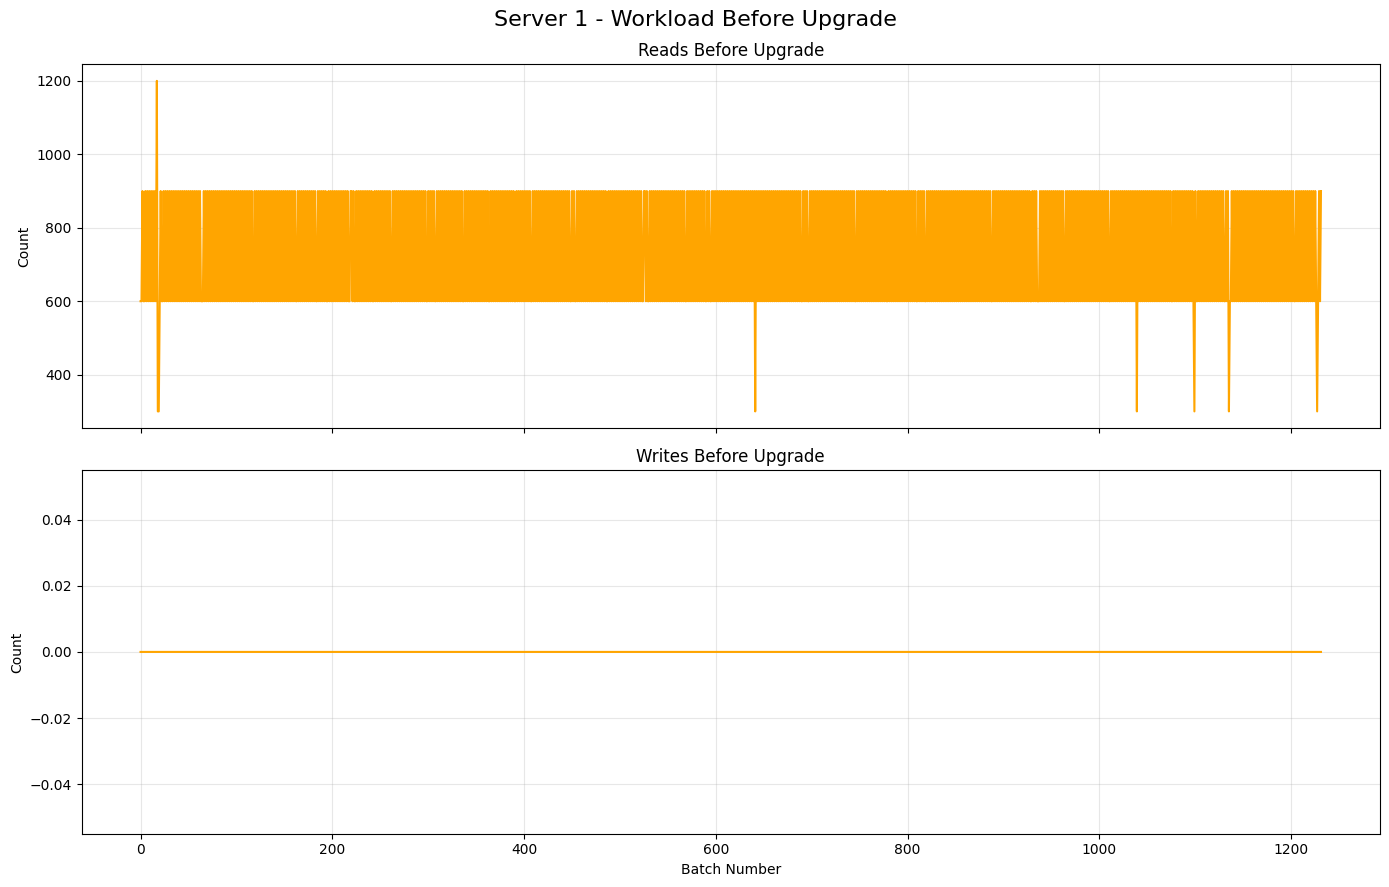

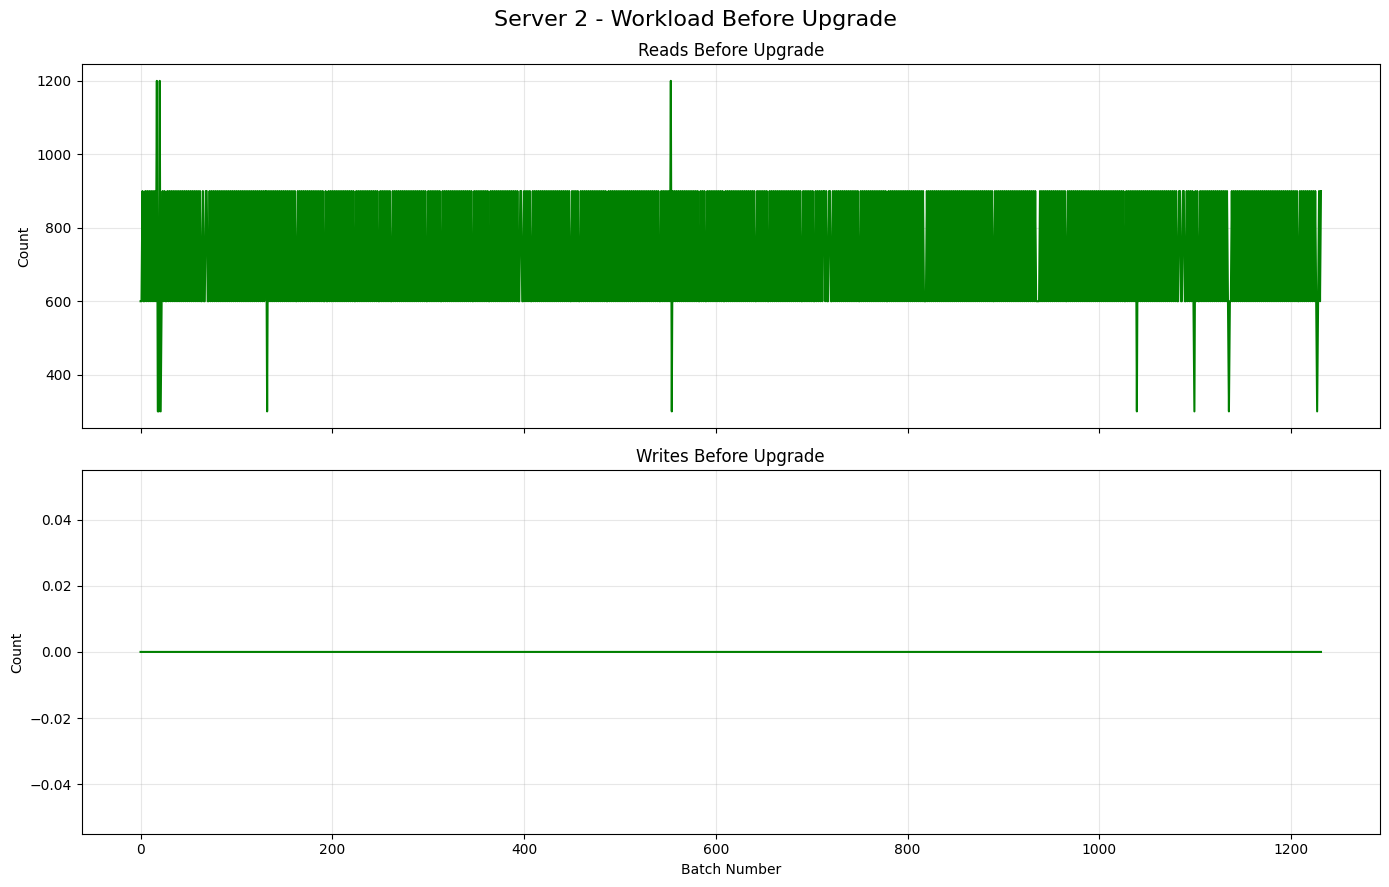

File not found: ./batch_mix_before_after_3.csv
File not found: ./batch_mix_before_after_4.csv
File not found: ./batch_mix_before_after_5.csv
File not found: ./batch_mix_before_after_6.csv
File not found: ./batch_mix_before_after_7.csv
File not found: ./batch_mix_before_after_8.csv
File not found: ./batch_mix_before_after_9.csv
File not found: ./batch_mix_before_after_10.csv
File not found: ./batch_mix_before_after_11.csv
File not found: ./batch_mix_before_after_12.csv
File not found: ./batch_mix_before_after_13.csv
File not found: ./batch_mix_before_after_14.csv

All plots generated successfully!


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

# Server IDs — update to match the number of servers started in Servers.java
NUM_SERVERS = 15
SERVER_IDS = list(range(NUM_SERVERS))

COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_tps(server_ids=SERVER_IDS):
    """Plot system TPS metrics from tps_<id>.csv for each server"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0, 0].plot(df.index, df['CurrentTPS'], color=color, linewidth=1, label=label)
        axes[0, 1].plot(df.index, df['Profit'], color=color, linewidth=1, label=label)
        axes[1, 0].plot(df.index, df['TokensUsed'], color=color, linewidth=1, label=label)
        axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color=color, linewidth=1, label=label)

    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number'); axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend()

    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number'); axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend()

    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number'); axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend()

    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number'); axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def plot_incoming_transaction_rate(server_ids=SERVER_IDS):
    """Plot incoming transaction rate.
    - Top row:  per-server files  incoming_transaction_rate_<id>.csv  (received by each server)
    - Bottom row: global injector  incoming_transaction_rate_global.csv  (sent by Servers.java)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle('Incoming Transaction Rate Metrics', fontsize=16)

    # Per-server received rates
    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"incoming_transaction_rate_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        axes[0].plot(df.index, df['IncomingTransactionCount'], color=color, linewidth=1,
                     marker='o', markersize=2, label=f"Server {sid}")
        axes[1].plot(df.index, df['IncomingTPS'], color=color, linewidth=1,
                     marker='s', markersize=2, label=f"Server {sid}")

    axes[0].set_title('Incoming Transaction Count per Batch (per server)')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Transaction Count')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Incoming Transaction Rate — per server (TPS)')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Incoming TPS')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    # Global injector rate
    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[2].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5,
                     marker='D', markersize=2, label='Global injector')
        axes[2].fill_between(df_g.index, df_g['IncomingTPS'], alpha=0.15, color='black')
        window_size = min(20, len(df_g) // 5) if len(df_g) > 5 else 1
        if window_size > 1:
            df_g['TPS_MA'] = df_g['IncomingTPS'].rolling(window=window_size).mean()
            axes[2].plot(df_g.index, df_g['TPS_MA'], color='orange', linewidth=2,
                         label=f'Moving Avg ({window_size})')
    else:
        axes[2].text(0.5, 0.5, 'incoming_transaction_rate_global.csv not found',
                     ha='center', va='center', transform=axes[2].transAxes)

    axes[2].set_title('Global Injector Transaction Rate (TPS)')
    axes[2].set_xlabel('Batch Number'); axes[2].set_ylabel('Incoming TPS')
    axes[2].grid(True, alpha=0.3); axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_backlog(server_ids=SERVER_IDS):
    """Plot backlog metrics from backlog_<id>.csv"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)
        axes[0].fill_between(df.index, df['Backlog'], alpha=0.1, color=color)

        window_size = min(50, len(df) // 10) if len(df) > 10 else 1
        if window_size > 1:
            df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=0.5, alpha=0.4, label=f"Server {sid} raw")
            axes[1].plot(df.index, df['Backlog_MA'], color=color, linewidth=2,
                         linestyle='--', label=f"Server {sid} MA({window_size})")
        else:
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)

    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_writeconcern_frequency(server_ids=SERVER_IDS):
    """Plot before/after writeConcern mix from batch_mix_before_after_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 1,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern Frequency Per Batch (Before vs After, per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        before_wc_columns = [col for col in df.columns if col.startswith('BeforeWriteWC') and col != 'BeforeWriteWCOther']
        after_wc_columns = [col for col in df.columns if col.startswith('AfterWriteWC') and col != 'AfterWriteWCOther']

        for col in before_wc_columns:
            wc_label = col.replace('BeforeWrite', '')
            ax.plot(df.index, df[col], label=f'Before-{wc_label}', linewidth=1)

        for col in after_wc_columns:
            wc_label = col.replace('AfterWrite', '')
            ax.plot(df.index, df[col], label=f'After-{wc_label}', linewidth=1, linestyle='--')

        ax.set_title(f"Server {sid} — WriteConcern Frequency (Before vs After)")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_writeconcern_tps(server_ids=SERVER_IDS):
    """Plot writeConcern TPS from writeconcern_tps_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 2,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern TPS (per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"writeconcern_tps_{sid}.csv")
        ax_wc, ax_sys = axes_list[i][0], axes_list[i][1]
        if not os.path.exists(filepath):
            ax_wc.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
        for col in wc_tps_columns:
            ax_wc.plot(df.index, df[col], label=col, linewidth=1)
        ax_wc.set_title(f"Server {sid} — WriteConcern TPS")
        ax_wc.set_xlabel('Batch Number'); ax_wc.set_ylabel('TPS')
        ax_wc.legend(loc='upper right'); ax_wc.grid(True, alpha=0.3)
        if 'SystemTPS' in df.columns:
            ax_sys.plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        ax_sys.set_title(f"Server {sid} — System TPS")
        ax_sys.set_xlabel('Batch Number'); ax_sys.set_ylabel('TPS')
        ax_sys.legend(loc='upper right'); ax_sys.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def smooth_count_series(series):
    """Reduce high-frequency 1-step toggling that visually looks like a filled area."""
    s = pd.to_numeric(series, errors='coerce').astype(float)
    if s.notna().sum() < 5:
        return s
    # Use a centered rolling median to keep the trend while removing ping-pong noise.
    return s.rolling(window=21, center=True, min_periods=1).median()


def plot_read_mix_before_after(server_ids=SERVER_IDS):
    """Plot separate readConcern panels (before vs after) for each server."""
    concerns = [
        ('ReadEventual', 'EVENTUAL'),
        ('ReadCausalLocal', 'CAUSAL_LOCAL'),
        ('ReadCausalMajority', 'CAUSAL_MAJORITY'),
        ('ReadLinearizable', 'LINEARIZABLE')
    ]

    for sid in server_ids:
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
        fig.suptitle(f'Server {sid} — Read Mix Before vs After (per ReadConcern)', fontsize=15)

        for idx, (suffix, label) in enumerate(concerns):
            ax = axes[idx // 2][idx % 2]
            b_col = f'Before{suffix}'
            a_col = f'After{suffix}'

            has_data = False
            if b_col in df.columns:
                b_vals = smooth_count_series(df[b_col])
                ax.plot(df.index, b_vals, linewidth=1.8, label='Before')
                has_data = True
            if a_col in df.columns:
                a_vals = smooth_count_series(df[a_col])
                ax.plot(df.index, a_vals, linewidth=1.8, linestyle='--', label='After')
                has_data = True

            ax.set_title(label)
            ax.set_xlabel('Batch Number')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)
            if has_data:
                ax.legend(loc='upper right')
            else:
                ax.text(0.5, 0.5, f'Missing columns: {b_col}/{a_col}',
                        ha='center', va='center', transform=ax.transAxes)

        plt.tight_layout()
        plt.show()


def plot_batch_avg_tps():
    """Plot batch average TPS from final_batch_avg_tps_log.csv (global file)"""
    filepath = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    df = pd.read_csv(filepath, header=None, names=['Timestamp', 'BatchAvgTPS'])
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Final Batch Average TPS Metrics', fontsize=16)
    axes[0].plot(df.index, df['BatchAvgTPS'], color='teal', linewidth=1)
    axes[0].set_title('Batch Average TPS')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('TPS')
    axes[0].grid(True, alpha=0.3)
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['BatchAvgTPS_MA'] = df['BatchAvgTPS'].rolling(window=window_size).mean()
        axes[0].plot(df.index, df['BatchAvgTPS_MA'], color='orange', linewidth=2,
                     label=f'Moving Avg ({window_size})')
        axes[0].legend()
    axes[1].hist(df['BatchAvgTPS'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_title('Distribution of Batch Average TPS')
    axes[1].set_xlabel('TPS'); axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    mean_tps = df['BatchAvgTPS'].mean()
    median_tps = df['BatchAvgTPS'].median()
    axes[1].axvline(mean_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tps:.0f}')
    axes[1].axvline(median_tps, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tps:.0f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print(f"\n📊 Batch Average TPS Statistics:")
    print(f"   Mean: {mean_tps:.2f}")
    print(f"   Median: {median_tps:.2f}")
    print(f"   Min: {df['BatchAvgTPS'].min():.2f}")
    print(f"   Max: {df['BatchAvgTPS'].max():.2f}")
    print(f"   Std Dev: {df['BatchAvgTPS'].std():.2f}")


def plot_combined_view(server_ids=SERVER_IDS):
    """Create a combined dashboard view overlaying all servers"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard (all servers)', fontsize=18)

    for i, sid in enumerate(server_ids):
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"

        tps_file = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if os.path.exists(tps_file):
            df_tps = pd.read_csv(tps_file)
            axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color=color, linewidth=1, label=label)

        backlog_file = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if os.path.exists(backlog_file):
            df_backlog = pd.read_csv(backlog_file)
            axes[1].plot(df_backlog.index, df_backlog['Backlog'], color=color, linewidth=1, label=label)
            axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.1, color=color)

        mix_file = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if os.path.exists(mix_file):
            df_mix = pd.read_csv(mix_file)
            if 'BeforeWrites' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['BeforeWrites'], linewidth=1, label=f"S{sid}-BeforeWrites")
            if 'AfterWrites' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['AfterWrites'], linewidth=1, linestyle='--', label=f"S{sid}-AfterWrites")
            if 'BeforeReads' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['BeforeReads'], linewidth=1, label=f"S{sid}-BeforeReads")
            if 'AfterReads' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['AfterReads'], linewidth=1, linestyle='--', label=f"S{sid}-AfterReads")

    axes[0].set_title('System TPS Over Time'); axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS'); axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Backlog Over Time'); axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size'); axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

    axes[2].set_title('Batch Mix Before vs After (Reads/Writes)'); axes[2].set_xlabel('Batch Number')
    axes[2].set_ylabel('Count'); axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)

    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[3].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5, label='Global injector TPS')
        axes[3].set_title('Global Injector — Incoming Transaction Rate (TPS)')
        axes[3].set_xlabel('Batch Number'); axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_stacked_area_frequency(server_ids=SERVER_IDS):
    """Plot stacked area chart for writeConcern distribution (before vs after) per server"""
    n = len(server_ids)
    fig, axes_list = plt.subplots(n, 1, figsize=(14, 5 * n), squeeze=False)
    fig.suptitle('WriteConcern Distribution Over Time (Before vs After, stacked)', fontsize=14)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)

        before_cols = [col for col in df.columns if col.startswith('BeforeWriteWC') and col != 'BeforeWriteWCOther']
        after_cols = [col for col in df.columns if col.startswith('AfterWriteWC') and col != 'AfterWriteWCOther']

        if before_cols:
            ax.stackplot(df.index, [df[col] for col in before_cols],
                        labels=[f'B-{c.replace("BeforeWrite", "")}' for c in before_cols], alpha=0.45)
        if after_cols:
            ax.stackplot(df.index, [df[col] for col in after_cols],
                        labels=[f'A-{c.replace("AfterWrite", "")}' for c in after_cols], alpha=0.30)

        ax.set_title(f"Server {sid} — WriteConcern Distribution (Before vs After)")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Transaction Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_workload_before_upgrade(server_ids=SERVER_IDS):
    """Plot pre-upgrade workload as separate figures per server."""
    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]

        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
        fig.suptitle(f'Server {sid} - Workload Before Upgrade', fontsize=16)

        if 'BeforeReads' in df.columns:
            axes[0].plot(df.index, df['BeforeReads'], color=color, linewidth=1.5)
        else:
            axes[0].text(0.5, 0.5, 'BeforeReads column not found',
                         ha='center', va='center', transform=axes[0].transAxes)

        if 'BeforeWrites' in df.columns:
            axes[1].plot(df.index, df['BeforeWrites'], color=color, linewidth=1.5)
        else:
            axes[1].text(0.5, 0.5, 'BeforeWrites column not found',
                         ha='center', va='center', transform=axes[1].transAxes)

        axes[0].set_title('Reads Before Upgrade')
        axes[0].set_ylabel('Count')
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title('Writes Before Upgrade')
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('Count')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)

    print("\n1. Plotting TPS metrics...")
    plot_tps()

    print("\n2. Plotting Incoming Transaction Rate...")
    plot_incoming_transaction_rate()

    print("\n3. Plotting Backlog...")
    plot_backlog()

    print("\n4. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()

    print("\n5. Plotting Read Mix (Before vs After)...")
    plot_read_mix_before_after()

    print("\n6. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()

    print("\n7. Plotting Final Batch Average TPS...")
    plot_batch_avg_tps()

    print("\n8. Plotting Combined Dashboard...")
    plot_combined_view()

    print("\n9. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()

    print("\n10. Plotting Workload Before Upgrade (Per Server)...")
    plot_workload_before_upgrade()

    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)


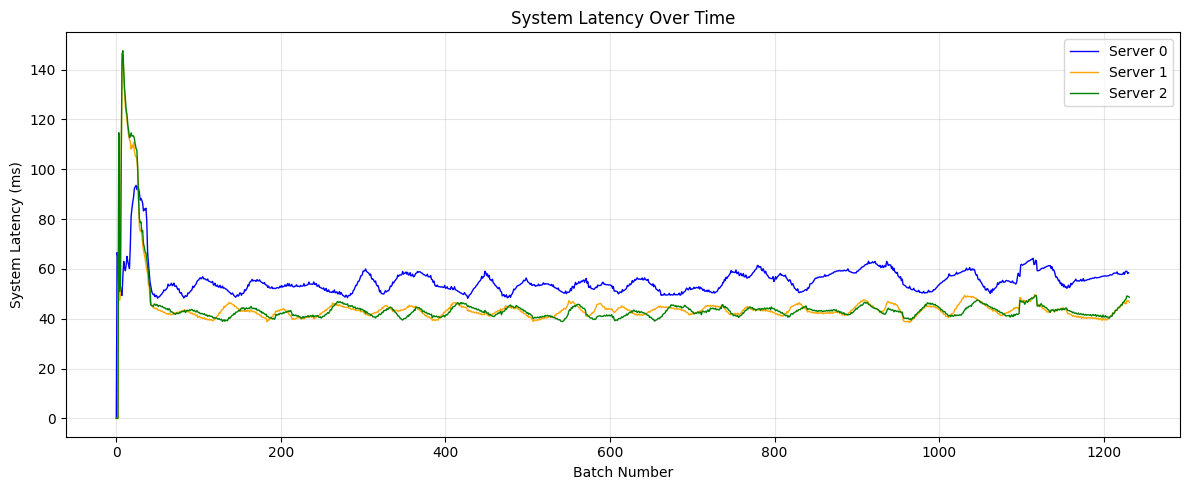

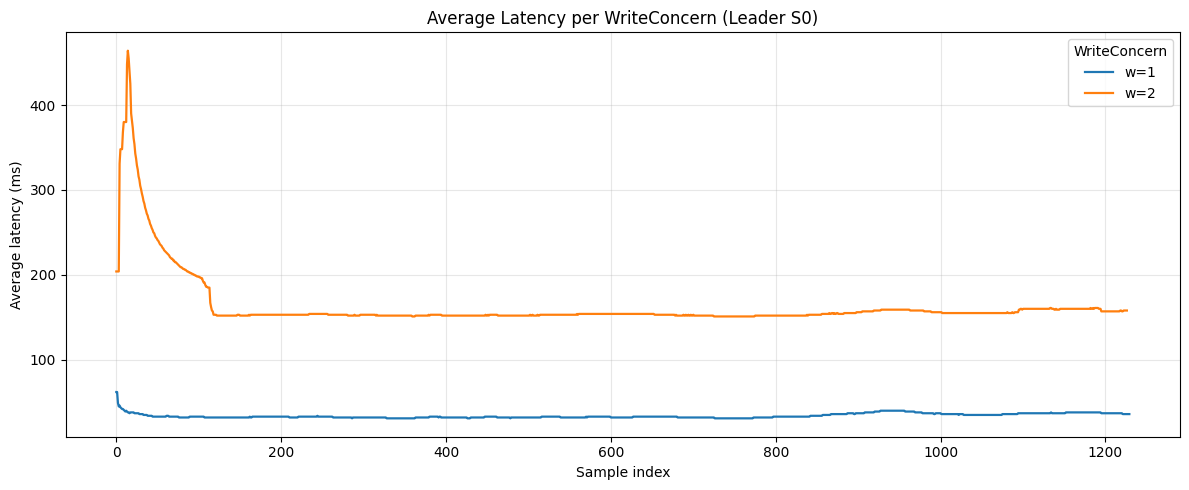

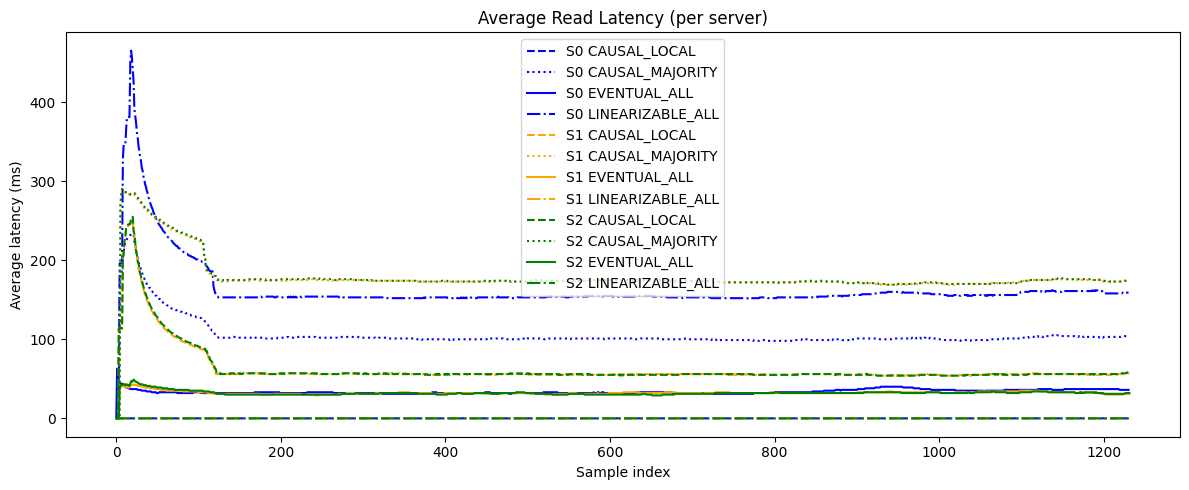

In [44]:
# Plot system latency and WC latencies per server
import pandas as pd
import matplotlib.pyplot as plt
import os

CSV_DIR = "."
NUM_SERVERS = 3
SERVER_IDS = list(range(NUM_SERVERS))
COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_system_latency(server_ids=SERVER_IDS):
    """Plot system latency from system_latency_<id>.csv for each server"""
    plt.figure(figsize=(12, 5))
    plt.title('System Latency Over Time')

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        plt.plot(df.index, df['SystemLatency'], linewidth=1,
                 color=COLORS[i % len(COLORS)], label=f"Server {sid}")

    plt.xlabel('Batch Number')
    plt.ylabel('System Latency (ms)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def detect_leader_by_positive_latency(server_ids=SERVER_IDS):
    """Pick the server with the strongest non-zero writeConcern latency signal."""
    best_sid = None
    best_score = -1.0

    for sid in server_ids:
        filepath = os.path.join(CSV_DIR, f"avg_latencies_{sid}.csv")
        if not os.path.exists(filepath):
            continue

        df = pd.read_csv(filepath, header=None, names=["wc", "avgLatency"])
        df_pos = df[df["avgLatency"] > 0].copy()
        if df_pos.empty:
            continue

        score = float(df_pos["avgLatency"].mean())
        if score > best_score:
            best_score = score
            best_sid = sid

    return best_sid


def plot_wc_latencies(server_ids=SERVER_IDS):
    """Plot average latency per writeConcern for the leader only (non-zero latencies)."""
    leader_sid = detect_leader_by_positive_latency(server_ids)
    if leader_sid is None:
        print("No leader with positive writeConcern latencies found.")
        return

    filepath = os.path.join(CSV_DIR, f"avg_latencies_{leader_sid}.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return

    df = pd.read_csv(filepath, header=None, names=["wc", "avgLatency"])
    df = df[df["avgLatency"] > 0].copy()
    if df.empty:
        print(f"Leader {leader_sid} has no positive writeConcern latency samples.")
        return

    plt.figure(figsize=(12, 5))
    plt.title(f'Average Latency per WriteConcern (Leader S{leader_sid})')

    wc_values = sorted(df["wc"].dropna().unique())
    cmap = plt.get_cmap("tab10")

    for idx, wc in enumerate(wc_values):
        group = df[df["wc"] == wc].reset_index(drop=True)
        color = cmap(idx % 10)
        plt.plot(group.index, group["avgLatency"],
                 color=color, linewidth=1.6, label=f"w={int(wc)}")

    plt.xlabel("Sample index")
    plt.ylabel("Average latency (ms)")
    plt.grid(True, alpha=0.3)
    plt.legend(title="WriteConcern")
    plt.tight_layout()
    plt.show()


def plot_read_latencies(server_ids=SERVER_IDS):
    """Plot average read latency from read_latencies_<id>.csv for each server.
    Supports both old format (ReadConcern) and new format (ReadLatencyKey).
    """
    plt.figure(figsize=(12, 5))
    plt.title('Average Read Latency (per server)')

    line_style_map = {
        'EVENTUAL_ALL': '-',
        'CAUSAL_LOCAL': '--',
        'CAUSAL_MAJORITY': ':',
        'LINEARIZABLE_ALL': '-.',
        'EVENTUAL': '-',
        'CAUSAL': '--',
        'LINEARIZABLE': ':'
    }

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"read_latencies_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)

        if 'ReadLatencyKey' in df.columns:
            group_col = 'ReadLatencyKey'
        elif 'ReadConcern' in df.columns:
            group_col = 'ReadConcern'
        else:
            print(f"Server {sid} — Missing ReadLatencyKey/ReadConcern column in {filepath}. Columns: {list(df.columns)}")
            continue

        if 'AvgLatencyMs' in df.columns:
            value_col = 'AvgLatencyMs'
        elif 'AvgLatency' in df.columns:
            value_col = 'AvgLatency'
        else:
            print(f"Server {sid} — Missing AvgLatencyMs/AvgLatency column in {filepath}. Columns: {list(df.columns)}")
            continue

        for key, group in df.groupby(group_col):
            key_str = str(key)
            linestyle = line_style_map.get(key_str, '-')
            plt.plot(range(len(group)), group[value_col],
                     color=COLORS[i % len(COLORS)],
                     linestyle=linestyle,
                     label=f"S{sid} {key_str}")

    plt.xlabel("Sample index")
    plt.ylabel("Average latency (ms)")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_system_latency()
plot_wc_latencies()
plot_read_latencies()


In [47]:
import pandas as pd
import os

CSV_DIR = "."
NUM_SERVERS = 15
SERVER_IDS = list(range(NUM_SERVERS))

WARMUP_MS = 15000  # 15 seconds

for sid in SERVER_IDS:
    latency_file = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")

    if os.path.exists(latency_file):

        df_latency = pd.read_csv(
            latency_file,
            header=None,
            names=["Timestamp", "SystemLatency"]
        )

        # convert to numeric
        df_latency["Timestamp"] = pd.to_numeric(df_latency["Timestamp"], errors="coerce")
        df_latency["SystemLatency"] = pd.to_numeric(df_latency["SystemLatency"], errors="coerce")

        df_latency = df_latency.dropna()

        if not df_latency.empty:

            start_time = df_latency["Timestamp"].iloc[0]

            # skip first 15 seconds
            df_after_warmup = df_latency[
                df_latency["Timestamp"] >= start_time + WARMUP_MS
            ]

            # take every other value
            df_sampled = df_after_warmup.iloc[::2]

            if not df_sampled.empty:
                avg_latency = df_sampled["SystemLatency"].mean()
                print(
                    f"Server {sid} — Average System Latency "
                    f"(skip 15s, every other sample): {avg_latency:.2f} ms"
                )
            else:
                print(f"Server {sid} — No data after warm-up filtering.")
        else:
            print(f"Server {sid} — File empty.")

    else:
        print(f"Server {sid} — File not found: {latency_file}")

Server 0 — Average System Latency (skip 15s, every other sample): 55.16 ms
Server 1 — Average System Latency (skip 15s, every other sample): 43.38 ms
Server 2 — Average System Latency (skip 15s, every other sample): 42.99 ms
Server 3 — File not found: ./system_latency_3.csv
Server 4 — File not found: ./system_latency_4.csv
Server 5 — File not found: ./system_latency_5.csv
Server 6 — File not found: ./system_latency_6.csv
Server 7 — File not found: ./system_latency_7.csv
Server 8 — File not found: ./system_latency_8.csv
Server 9 — File not found: ./system_latency_9.csv
Server 10 — File not found: ./system_latency_10.csv
Server 11 — File not found: ./system_latency_11.csv
Server 12 — File not found: ./system_latency_12.csv
Server 13 — File not found: ./system_latency_13.csv
Server 14 — File not found: ./system_latency_14.csv


File not found: ./backlog_samples_0.csv (expected columns: timestamp_ms,backlog,ema)
File not found: ./backlog_samples_1.csv (expected columns: timestamp_ms,backlog,ema)


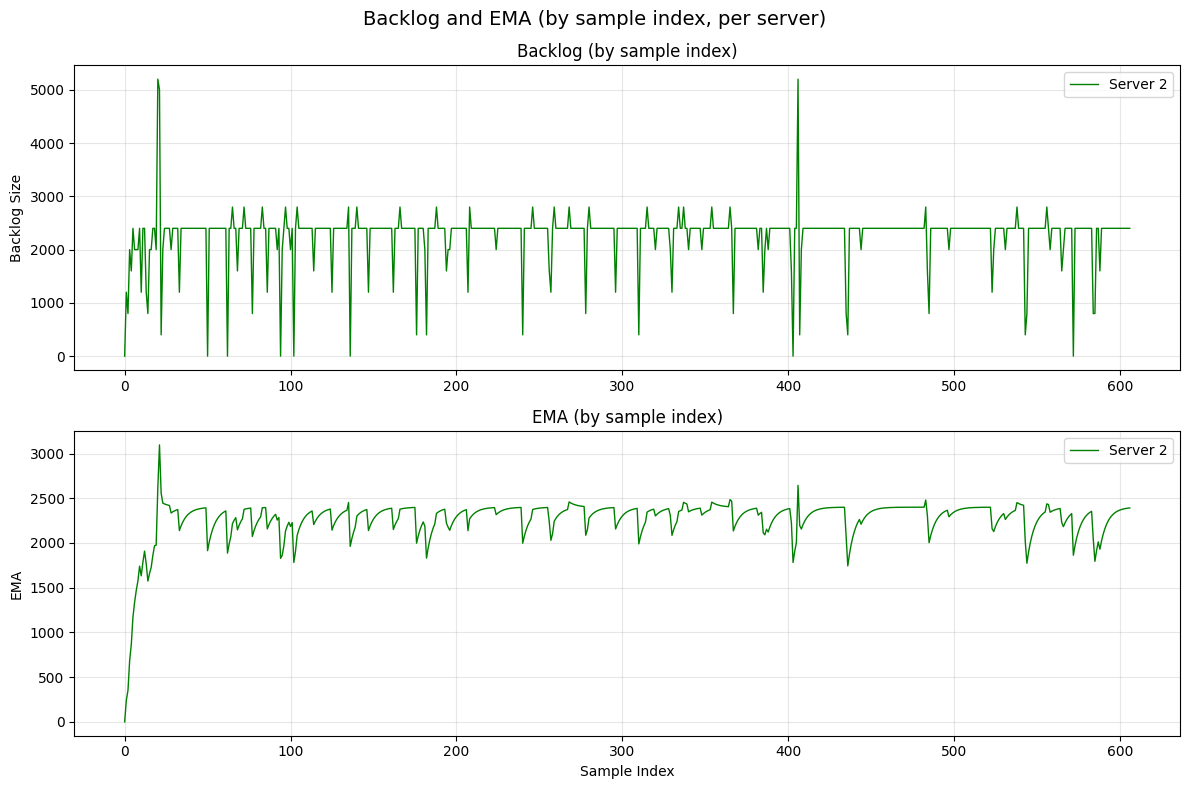

In [1]:
# Plot backlog and EMA from backlog_samples_<id>.csv for each server
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_DIR = "."
NUM_SERVERS = 3
SERVER_IDS = list(range(NUM_SERVERS))
COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_backlog_and_ema_samples(server_ids=SERVER_IDS):
    """Read backlog_samples_<id>.csv for each server and plot Backlog + EMA vs sample index"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    fig.suptitle('Backlog and EMA (by sample index, per server)', fontsize=14)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"backlog_samples_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath} (expected columns: timestamp_ms,backlog,ema)")
            continue
        df = pd.read_csv(filepath)
        cols = {c.lower(): c for c in df.columns}
        if 'backlog' not in cols or 'ema' not in cols:
            print(f"Server {sid} — Required columns 'backlog' and 'ema' not found.")
            continue
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0].plot(df.index, df[cols['backlog']], color=color, linewidth=1, label=label)
        axes[1].plot(df.index, df[cols['ema']], color=color, linewidth=1, label=label)

    axes[0].set_title('Backlog (by sample index)')
    axes[0].set_ylabel('Backlog Size'); axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('EMA (by sample index)')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('EMA'); axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_backlog_and_ema_samples()
